In [1]:
title = "# Introduction to Bayesian statistics: exercises"
# Print title and setup TeX defs for both KaTeX and MathJax
import bayesian_stats_course_tools
bayesian_stats_course_tools.misc.display_markdown_and_setup_tex(title)

import matplotlib.style
matplotlib.style.use("bayesian_stats_course_tools.light")

# Introduction to Bayesian statistics: exercises

<!-- Define LaTeX macros -->
$\def\E{\operatorname{E}}$
$\def\Var{\operatorname{Var}}$
$\def\Cov{\operatorname{Cov}}$
$\def\dd{\mathrm{d}}$
$\def\ee{\mathrm{e}}$
$\def\Norm{\mathcal{N}}$
$\def\Uniform{\mathcal{U}}$

<!-- MathJax needs them to be defined again for the non-inline environment -->
$$\def\E{\operatorname{E}}$$
$$\def\Var{\operatorname{Var}}$$
$$\def\Cov{\operatorname{Cov}}$$
$$\def\dd{\mathrm{d}}$$
$$\def\ee{\mathrm{e}}$$
$$\def\Norm{\mathcal{N}}$$
$$\def\Uniform{\mathcal{U}}$$

# Exercise 1

- Implement your own version of the line-fitting procedure, using the same data.
- Now try it with the data in `lectures/data/linear_fits/data_1.txt`
    - First plot the data. What has changed?
    - Try the same model and likelihood on the new data. You might want to adjust the prior on $m$ and $b$ for this new data set.
    - What if you use the provided uncertainty per data point $\sigma_{y_i}$, instead of assuming a constant variance $\sigma_y$ for all data points?
    - Instead use the actual likelihood of the data:
\begin{align}
    \mu(x) &= mx + b \\
    \sigma(x_i) &= \sigma_{y_i} + f\mu(x_i)^2 \quad f > 0\ \text{a parameter} \\
    y_i&\sim N(\mu(x_i),\sigma(x_i)^2)
\end{align}
Careful with the normalisation of the Gaussian likelihood. Because we vary the variance, this matters now!

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
import emcee
import corner


loading data "data_0.txt"

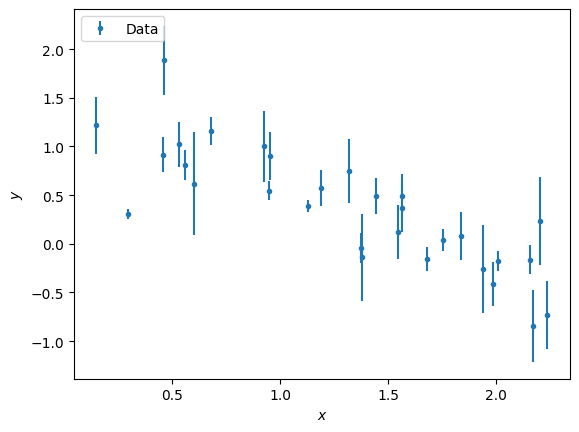

In [40]:
def plot_linear_data_set(x, y, y_err=None):
    """Plot linear data set and format the plot."""
    fig, ax = plt.subplots(1, 1)

    if y_err is not None:
        ax.errorbar(x, y, y_err, fmt=".", label="Data")
    else:
        ax.plot(x, y, marker=".", linestyle="none", label="Data")

    ax.set_xlabel("$x$")
    ax.set_ylabel("$y$")
    ax.legend(loc="upper left")

    return fig, ax

x, y, y_err = np.loadtxt("/Users/henri/Documents/Bayesian-Stats-HS2026/lectures/data/linear_fits/data_1.txt", unpack=True)

# For now, all errors are the same
#sigma_y = y_err[0]


sigma_y = y_err

_ = plot_linear_data_set(x, y, sigma_y)

copying the model from the lecture

MAP results
m_MAP = -0.357, b_MAP = 0.694


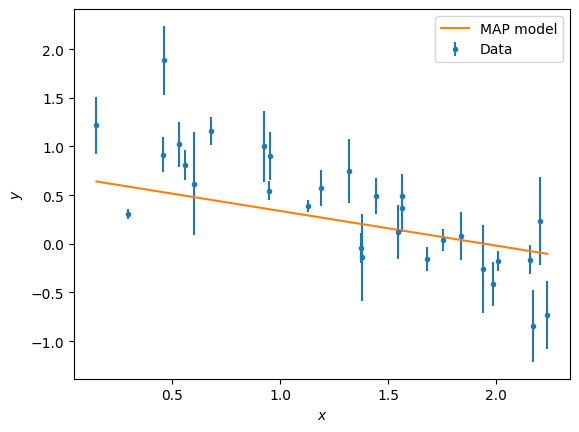

In [51]:
# ----------------
# The linear model
# ----------------

def model(m, b, x):
    return m*x + b

f = 0


m_prior = scipy.stats.norm(loc=1, scale=1)
b_prior = scipy.stats.norm(loc=0, scale=1.2)

# Probability of the data, given the model parameters: P(y|m, b)
# We use the logarithm here for computational reasons
def log_likelihood_probability(y, m, b, x, sigma_y):
    prediction = model(m, b, x)

    #n = len(y)
    # log of the PDF of a multivariate Gaussian
    return (
        -0.5 * np.sum((y - prediction)**2/(sigma_y + f * (m*x+b))**2)  # Exponent
        -0.5 * np.sum(np.log(2*np.pi*(sigma_y + f * (m*x+b))**2))               # Normalisation - this needs to be adjusted for sigma_i != sigma_j
    )

m_prior = scipy.stats.norm(loc=1, scale=1)
b_prior = scipy.stats.norm(loc=0, scale=1.2)

def log_prior_probability(m, b):
    return m_prior.logpdf(m) + b_prior.logpdf(b)


# ---------
# fit model
# ---------

def log_posterior_probability(m, b, x, sigma_y, y):
    return (
        log_likelihood_probability(y, m, b, x, sigma_y + f * (m*x+b))
        + log_prior_probability(m, b)
    )


# -----------
# compute map
# -----------


# The scipy minimizer finds the minimum, so we need to take the 
# negative of the posterior. The scipy minimizer also passes an array 
# with the parameters, this wrapper splits this array into m and b.
def negative_log_posterior(theta, x, sigma_y, y):
    m, b = theta
    return -log_posterior_probability(m, b, x, sigma_y, y)

MAP_result = scipy.optimize.minimize(
    fun=negative_log_posterior,
    x0=(1, 0),
    args=(x, sigma_y, y)
)
m_MAP, b_MAP = MAP_result.x

print("MAP results")
print(f"m_MAP = {m_MAP:.3f}, b_MAP = {b_MAP:.3f}")



# ------------------------
# plot MAP model vs values
# ------------------------

_, ax = plot_linear_data_set(x, y, sigma_y + f * (m_MAP*x+b_MAP))

x_grid = np.linspace(0, 2.5, 100)
ax.plot(x, model(m_MAP, b_MAP, x), c="C1", label="MAP model")
ax.legend();

In [52]:
# emcee passes an array of values for the sampled parameters
# This wrapper just splits the array theta into m and b
def log_posterior_wrapper(theta, x, sigma_y, y):
    m, b = theta
    return log_posterior_probability(m, b, x, sigma_y, y)

# emcee requires some extra settings to run
n_param = 2       # Number of parameter we are sampling
n_walker = 10     # Number of walkers. This just needs to be 
                  # larger than 2*n_param + 1!
n_step = 5000     # How many steps each walker will take. The number
                  # of samples will be n_walker*n_step

# The starting point for each walker
theta_init = np.array([0.5, 0.5]) \
    + 0.1*np.random.normal(size=(n_walker, n_param))

sampler = emcee.EnsembleSampler(
    nwalkers=n_walker, ndim=n_param,
    log_prob_fn=log_posterior_wrapper,
    args=(x, sigma_y, y)
)
state = sampler.run_mcmc(theta_init, nsteps=n_step)

In [53]:
# The samples will be correlated, this checks how correlated they are
# We will discuss this once we come to MCMC methods
print("Auto-correlation time:")
for name, value in zip(["m", "b", "f"], sampler.get_autocorr_time()):
    print(f"{name} = {value:.1f}")

# We need to discard the beginning of the chain (a few auto-correlation times)
# to get rid of the initial conditions
chain = sampler.get_chain(discard=300, thin=10, flat=True)

print("Posterior results (mean±std)")
print(f"m = {np.mean(chain[:,0]):.2f}±{np.std(chain[:,0]):.2f}")
print(f"b = {np.mean(chain[:,1]):.2f}±{np.std(chain[:,1]):.2f}")

Auto-correlation time:
m = 39.8
b = 38.7
Posterior results (mean±std)
m = -0.36±0.04
b = 0.69±0.05


In [49]:
fig = plt.figure()
fig = corner.corner(
    chain,
    bins=40,
    labels=["m", "b"],
    color="C0",
    truth_color="C1",
    levels=1-np.exp(-0.5*np.array([1, 2])**2), # Credible contours corresponding
                                               # to 1 and 2 sigma in 2D
    quantiles=[0.025, 0.16, 0.84, 0.975],
    fig=fig
);
fig.get_axes()[0].plot([], [], c="C0", label="Samples from the posterior")
fig.get_axes()[0].legend(loc=2, bbox_to_anchor=(1, 1))
plt.close()

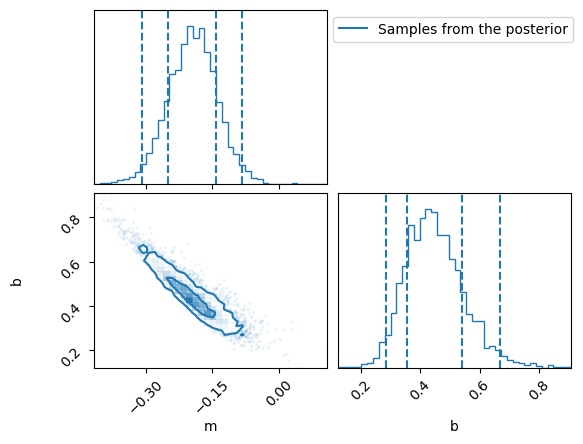

In [50]:
fig

# Exercise 2

The data in the previous example were a synthetic version of real observations that were obtained in an AstroWoche project in 2024 by Jonas Spiller, Theo Lequy, Clara Bleich. 

<!-- ![jovian moons data](../assets/jovian_moons_raw_data.png) -->
<img style="display: block; 
    margin-left: auto;
    margin-right: auto;
    width: 60%;"
    src="../assets/jovian_moons_raw_data.png" alt="jovian moons data"/>

The real observations can be found in `data/jovian_moons/{moon}.dat`:

In [ ]:
moon = "Io"

t, distance, distance_alt, distance_err = np.loadtxt(
    f"./data/jovian_moons/{moon}.dat", unpack=True)

1. Repeat the analysis with the real data set. What do you find?

There is another distance estimate provided. The difference between the distance estimates comes from different approaches to converting the measured distance between Jupiter and its moons from the number of pixels to a physical distance in km.

2. How does the analysis look when using this other distance estimate (what I call `distance_alt`)? What about the other moons?



Because there are two distance estimates that do not agree, both of which are based on reasonable approaches, this suggests that there might be a _systematic_ error in the measurements. Systematic errors are usually not random (which means they do not get smaller as you obtain more data). But we could pretend the offset between the two measurements is an estimate of an unaccounted statistical uncertainty. 

3. How does the analysis look when we assume `sigma_d**2 = distance_err**2 + (distance - distance_alt)**2`?



4. Instead of assuming that the uncertainty is underestimated by this offset, we can also model it. Does the model work better if the variance is a free parameter?


In [54]:
def plot_data(t, distance, distance_err, subtract_y=None):
    fig, ax = plt.subplots()

    if subtract_y is None:
        ax.errorbar(t, distance, distance_err, linestyle="none", marker=".", label="Data")
        ax.set_ylabel("Projected distance to Jupiter [$10^6$ km]")
    else:
        ax.axhline(0, color="dimgrey", lw=1)
        ax.errorbar(t, distance-subtract_y, distance_err, linestyle="none", marker=".", label="Data")
        ax.set_ylabel("Residual projected distance to Jupiter [$10^6$ km]")
    
    ax.set_xlabel("Time since 2024-01-08 18:00 [h]")

    return fig, ax

def plot_quantiles(ax, x, quantiles, **style):
    n_quantiles = len(quantiles)
    default_style = dict(alpha=0.5, color="C1", label="")
    style = {**default_style, **style}
    label = style.pop("label")
    for lower, upper in zip(quantiles[:n_quantiles//2], quantiles[n_quantiles//2+1::-1]):
        ax.fill_between(x, lower, upper, **style)


In [62]:
moon = "Io"

t, distance, distance_alt, distance_err = np.loadtxt(
    f"/Users/henri/Documents/Bayesian-Stats-HS2026/lectures/data/jovian_moons/Callisto.dat", unpack=True)

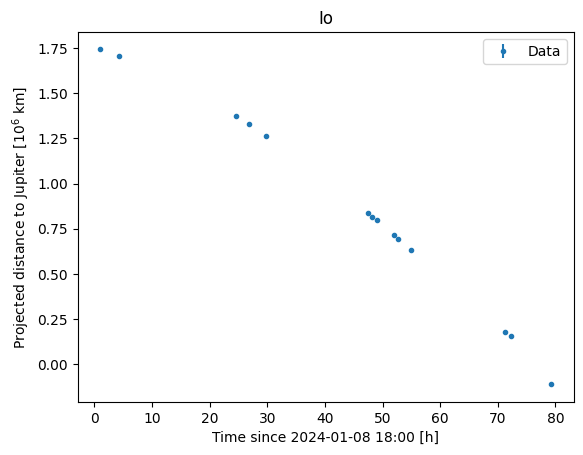

In [63]:
fig, ax = plot_data(t, distance, distance_err)
ax.legend()
_ = ax.set_title(f"{moon}")

In [64]:
def model(theta, t):
    semimajor, period, phi = theta
    return semimajor * np.sin(2*np.pi/period * t + phi)

In [65]:
def build_likelihood():
    # Sample new data from the likelihood
    def predict(theta, t, sigma_d):
        mu = model(theta, t)
        return np.random.normal(loc=mu, scale=sigma_d)

    # Evaluate the log-likelihood
    def log_likelihood(d, theta, t, sigma_d):
        mu = model(theta, t)

        n = len(d)
        return (
            -0.5 * np.sum((d - mu)**2/sigma_d**2)  # Exponent
            - n * 0.5 * np.log(2*np.pi) - 0.5 * np.sum(np.log(sigma_d**2)) # Normalisation
        )
    
    return predict, log_likelihood

In [66]:
def build_prior():
    low_a, high_a = 0.0, 3.0
    low_T, high_T = 10, 100
    low_phi, high_phi = 0, 2*np.pi

    def sample_from_prior(n):
        semimajor = np.random.uniform(low=low_a, high=high_a, size=(n,))
        period = np.random.uniform(low=low_T, high=high_T, size=(n,))
        phase = np.random.uniform(low=low_phi, high=high_phi, size=(n,))

        return np.stack((semimajor, period, phase)).T

    def log_prior(theta):
        semimajor, period, phase = theta
        if (semimajor < low_a or high_a < semimajor
                or period < low_T or high_T < period
                or phase < low_phi or high_phi < phase):
            return -np.inf
        return 0 # ignore normalisation for now

    return sample_from_prior, log_prior

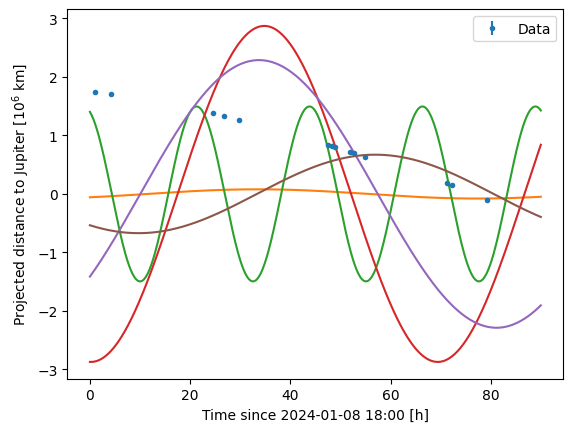

In [67]:
sample_from_likelihood, log_likelihood = build_likelihood()
sample_from_prior, log_prior = build_prior()

t_fine = np.linspace(0, 90, 500)

fig, ax = plot_data(t, distance, distance_err)

for p in sample_from_prior(5):
    ax.plot(t_fine, model(p, t_fine))

_ = ax.legend()

In [68]:
def log_posterior(theta, t, sigma_d, d):
    prior = log_prior(theta)
    if not np.isfinite(prior):
        return prior
    return log_likelihood(d, theta, t, sigma_d) + prior

log_posterior(sample_from_prior(1)[0], t, distance_err, distance)

# Make the output on the slides look nice
import warnings
warnings.filterwarnings('ignore')

In [69]:
MAP_result = scipy.optimize.minimize(
    fun=lambda theta: -log_posterior(theta=theta, t=t,
                                     sigma_d=distance_err, d=distance),
    x0=(1.0, 40.0, 1.0)
)

In [70]:
print(f"Optimisation successful: {MAP_result.success}")


Optimisation successful: False
